In [1]:
from pathlib import Path
import json
import math
import re
import pandas as pd
import matplotlib.pyplot as plt

CANDIDATE_ID = "CN-5164"
DATA_FILE = "CN-5164-contacts.csv"

if not Path(DATA_FILE).exists():
    try:
        from google.colab import files
        print(f"Upload your assigned file: {DATA_FILE}")
        files.upload()
    except ImportError:
        pass

if not Path(DATA_FILE).exists():
    raise FileNotFoundError(f"Could not find {DATA_FILE}")

raw_df = pd.read_csv(DATA_FILE)
print(f"Candidate: {CANDIDATE_ID}")
print(f"Loaded {len(raw_df)} rows and {len(raw_df.columns)} columns")
raw_df.head()


Upload your assigned file: CN-5164-contacts.csv


Saving CN-5164-contacts.csv to CN-5164-contacts.csv
Candidate: CN-5164
Loaded 191 rows and 10 columns


,contact_id,started_at,channel,queue,agent_id,wait_seconds,handle_seconds,outcome,customer_message,customer_rating
0,CN-5164-CT-0018,2026-07-05T21:56:00+00:00,email,technical,A002,191,568,transferred,I think this transaction is fraud,3
1,CN-5164-CT-0176,2026-07-07T08:45:00+00:00,EMAIL,Billing,A011,207,739,RESOLVED,I want to know the current plan,5
2,CN-5164-CT-0125,2026-07-08T13:06:00+00:00,chat,Technical,A004,46,0,abandoned,Need help with my account,2
3,CN-5164-CT-0165,2026-07-06T10:36:00+00:00,email,Support,A012,-10,858,callback,Please process a refund,NaN
4,CN-5164-CT-0140,invalid timestamp,EMAIL,sales,NaN,59,0,abandoned,The previous agent transferred me,bad


In [2]:
raw_df.info()
display(raw_df.isna().sum().to_frame("missing_values"))
for column in ["channel", "queue", "outcome"]:
    print(f"\nValues in {column}:")
    display(raw_df[column].value_counts(dropna=False).head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   contact_id        191 non-null    object
 1   started_at        191 non-null    object
 2   channel           169 non-null    object
 3   queue             176 non-null    object
 4   agent_id          173 non-null    object
 5   wait_seconds      191 non-null    object
 6   handle_seconds    191 non-null    int64 
 7   outcome           191 non-null    object
 8   customer_message  171 non-null    object
 9   customer_rating   142 non-null    object
dtypes: int64(1), object(9)
memory usage: 15.1+ KB


,missing_values
contact_id,0
started_at,0
channel,22
queue,15
agent_id,18
wait_seconds,0
handle_seconds,0
outcome,0
customer_message,20
customer_rating,49



Values in channel:


,count
channel,
email,36
CHAT,30
voice,25
chat,25
NaN,22
EMAIL,20
social,17
VOICE,16



Values in queue:


,count
queue,
Support,25
technical,23
Billing,22
support,22
sales,19
Sales,18
billing,17
retention,16
NaN,15



Values in outcome:


,count
outcome,
abandoned,43
resolved,29
RESOLVED,28
transferred,27
TRANSFERRED,23
callback,21
unresolved,20


In [4]:
def clean_contacts(df):
    out = df.copy()

    #  Standardise contact IDs and remove missing/blank IDs.
    out["contact_id"] = out["contact_id"].astype("string").str.strip()
    out = out[out["contact_id"].notna() & out["contact_id"].ne("")].copy()

    #  Parse ISO or DD/MM/YYYY HH:MM timestamps as timezone-aware UTC.
    timestamp_text = out["started_at"].astype("string").str.strip()

    def parse_timestamp(value):
        if pd.isna(value):
            return pd.NaT
        value = str(value).strip()
        if not value:
            return pd.NaT
        # ISO-8601 values may contain an explicit timezone.
        if "T" in value or value.endswith("Z") or re.search(r"[+-]\\d\\d:\\d\\d$", value):
            return pd.to_datetime(value, errors="coerce", utc=True)
        # The alternative source format is explicitly day/month/year.
        return pd.to_datetime(
            value, errors="coerce", utc=True, format="%d/%m/%Y %H:%M"
        )

    out["started_at"] = timestamp_text.map(parse_timestamp)
    out = out[out["started_at"].notna()].copy()

    #  Keep the first remaining occurrence of each ID in original order.
    out = out.drop_duplicates(subset="contact_id", keep="first")

    #  Canonicalise text labels case-insensitively.
    def canonical(value, allowed, default):
        if pd.isna(value):
            return default
        value = str(value).strip().lower()
        return value if value in allowed else default

    out["channel"] = out["channel"].map(
        lambda x: canonical(x, {"voice", "chat", "email"}, "unknown")
    )

    # The assigned dataset contains these five queue values.
    valid_queues = {"billing", "support", "technical", "sales", "retention"}
    out["queue"] = out["queue"].map(
        lambda x: canonical(x, valid_queues, "unassigned")
    )

    out["outcome"] = out["outcome"].map(
        lambda x: canonical(
            x, {"resolved", "abandoned", "transferred", "unresolved"}, "unresolved"
        )
    )

    # Numeric duration fields: invalid and negative values become missing.
    for column in ["wait_seconds", "handle_seconds"]:
        values = pd.to_numeric(out[column], errors="coerce")
        out[column] = values.mask(values < 0)

    #  Only whole-number ratings from 1 through 5 are valid.
    ratings = pd.to_numeric(out["customer_rating"], errors="coerce")
    valid_rating = (
        ratings.between(1, 5)
        & ratings.notna()
        & ratings.mod(1).eq(0)
    )
    out["customer_rating"] = ratings.where(valid_rating)

    #  Standardise agent/message fields.
    out["agent_id"] = out["agent_id"].astype("string").str.strip()
    out["agent_id"] = out["agent_id"].fillna("unassigned")
    out.loc[out["agent_id"].eq(""), "agent_id"] = "unassigned"

    out["customer_message"] = (
        out["customer_message"].astype("string").str.strip().fillna("")
    )

    #  Preserve original column order and reset the index.
    return out.loc[:, df.columns].reset_index(drop=True)

In [5]:
clean_df = clean_contacts(raw_df)

# Visible contract checks. Hidden tests use different data.
assert isinstance(clean_df, pd.DataFrame)
assert clean_df is not raw_df
assert clean_df.index.tolist() == list(range(len(clean_df)))
assert clean_df["contact_id"].notna().all()
assert clean_df["contact_id"].astype(str).str.strip().ne("").all()
assert clean_df["contact_id"].is_unique
assert set(clean_df["channel"].unique()) <= {"voice", "chat", "email", "unknown"}
assert clean_df["queue"].notna().all(), "queue column should have no missing values after cleaning"
assert set(clean_df["outcome"].unique()) <= {"resolved", "abandoned", "transferred", "unresolved"}
assert clean_df["wait_seconds"].dropna().ge(0).all()
assert clean_df["handle_seconds"].dropna().ge(0).all()
print(f"Cleaned rows: {len(clean_df)}")
clean_df.head()

Cleaned rows: 120


,contact_id,started_at,channel,queue,agent_id,wait_seconds,handle_seconds,outcome,customer_message,customer_rating
0,CN-5164-CT-0018,2026-07-05 21:56:00+00:00,email,technical,A002,191.0,568.0,transferred,I think this transaction is fraud,3.0
1,CN-5164-CT-0176,2026-07-07 08:45:00+00:00,email,billing,A011,207.0,739.0,resolved,I want to know the current plan,5.0
2,CN-5164-CT-0125,2026-07-08 13:06:00+00:00,chat,technical,A004,46.0,0.0,abandoned,Need help with my account,2.0
3,CN-5164-CT-0165,2026-07-06 10:36:00+00:00,email,support,A012,NaN,858.0,unresolved,Please process a refund,NaN
4,CN-5164-CT-0030,2026-07-08 05:51:00+00:00,voice,sales,A009,81.0,894.0,unresolved,Please explain the latest invoice,NaN


In [6]:
def calculate_metrics(clean_df):
    """Return the metrics dictionary defined in the assignment brief."""
    total = len(clean_df)
    valid_wait = clean_df["wait_seconds"].dropna()

    return {
        "total_contacts": int(total),
        "voice_contacts": int((clean_df["channel"] == "voice").sum()),
        "chat_contacts": int((clean_df["channel"] == "chat").sum()),
        "email_contacts": int((clean_df["channel"] == "email").sum()),
        "unknown_channel_contacts": int((clean_df["channel"] == "unknown").sum()),
        "average_wait_seconds": (
            None if valid_wait.empty else round(float(valid_wait.mean()), 2)
        ),
        "p90_wait_seconds": (
            None if valid_wait.empty else round(float(valid_wait.quantile(0.90)), 2)
        ),
        "abandonment_rate_pct": (
            0.0 if total == 0
            else round(float((clean_df["outcome"] == "abandoned").sum() / total * 100), 2)
        ),
        "resolution_rate_pct": (
            0.0 if total == 0
            else round(float((clean_df["outcome"] == "resolved").sum() / total * 100), 2)
        ),
    }

metrics = calculate_metrics(clean_df)
display(pd.Series(metrics, name="value").to_frame())

,value
total_contacts,120.00
voice_contacts,24.00
chat_contacts,35.00
email_contacts,42.00
unknown_channel_contacts,19.00
average_wait_seconds,119.31
p90_wait_seconds,199.00
abandonment_rate_pct,23.33
resolution_rate_pct,29.17


In [7]:
def assign_priority(contact):
    """Return High, Medium or Low using the ordered rules in the brief."""
    outcome = str(contact.get("outcome", "")).strip().lower()

    if outcome == "abandoned":
        return "High"

    wait = contact.get("wait_seconds")
    if pd.notna(wait) and wait >= 180:
        return "High"

    message = contact.get("customer_message", "")
    if pd.isna(message):
        message = ""
    message = str(message).lower()
    if any(term in message for term in ["fraud", "charged twice", "refund"]):
        return "High"

    if outcome == "transferred":
        return "Medium"

    if pd.notna(wait) and wait >= 60:
        return "Medium"

    return "Low"


def build_queue_summary(clean_df):
    """Return the queue summary defined in the assignment brief."""
    grouped = clean_df.groupby("queue", dropna=False)

    summary = grouped.size().rename("contacts").to_frame()
    summary["average_wait_seconds"] = grouped["wait_seconds"].mean().round(2)
    summary["abandonment_rate_pct"] = (
        grouped["outcome"]
        .apply(lambda values: float((values == "abandoned").mean() * 100))
        .round(2)
    )

    return (
        summary.reset_index()
        [["queue", "contacts", "average_wait_seconds", "abandonment_rate_pct"]]
        .sort_values(["contacts", "queue"], ascending=[False, True])
        .reset_index(drop=True)
    )

In [8]:
clean_df = clean_df.copy()
clean_df["priority"] = clean_df.apply(assign_priority, axis=1)
queue_summary = build_queue_summary(clean_df)
display(clean_df.head())
display(queue_summary)

,contact_id,started_at,channel,queue,agent_id,wait_seconds,handle_seconds,outcome,customer_message,customer_rating,priority
0,CN-5164-CT-0018,2026-07-05 21:56:00+00:00,email,technical,A002,191.0,568.0,transferred,I think this transaction is fraud,3.0,High
1,CN-5164-CT-0176,2026-07-07 08:45:00+00:00,email,billing,A011,207.0,739.0,resolved,I want to know the current plan,5.0,High
2,CN-5164-CT-0125,2026-07-08 13:06:00+00:00,chat,technical,A004,46.0,0.0,abandoned,Need help with my account,2.0,High
3,CN-5164-CT-0165,2026-07-06 10:36:00+00:00,email,support,A012,NaN,858.0,unresolved,Please process a refund,NaN,High
4,CN-5164-CT-0030,2026-07-08 05:51:00+00:00,voice,sales,A009,81.0,894.0,unresolved,Please explain the latest invoice,NaN,Medium


,queue,contacts,average_wait_seconds,abandonment_rate_pct
0,support,33,102.28,33.33
1,sales,24,154.55,16.67
2,technical,23,95.00,8.70
3,billing,22,129.18,31.82
4,retention,11,119.70,18.18
5,unassigned,7,120.43,28.57


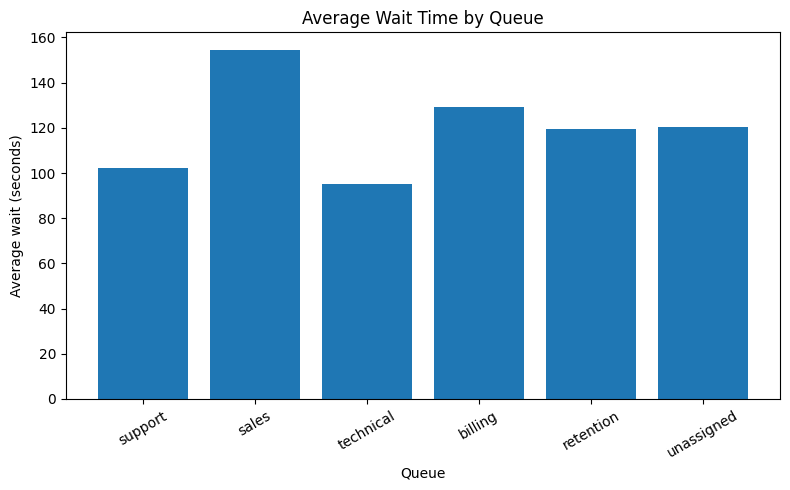

In [9]:
# Average wait by queue gives managers a direct view of where waiting time is highest.
plt.figure(figsize=(8, 5))
plt.bar(queue_summary["queue"], queue_summary["average_wait_seconds"])
plt.title("Average Wait Time by Queue")
plt.xlabel("Queue")
plt.ylabel("Average wait (seconds)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [10]:
raw_before = raw_df.copy(deep=True)
_ = clean_contacts(raw_df)
pd.testing.assert_frame_equal(raw_df, raw_before)

timestamp_test = pd.DataFrame({
    "contact_id": ["TEST-001"],
    "started_at": ["09/07/2026 14:30"],
    "channel": ["VOICE"],
    "queue": ["Support"],
    "agent_id": [None],
    "wait_seconds": ["0"],
    "handle_seconds": ["10"],
    "outcome": ["RESOLVED"],
    "customer_message": [None],
    "customer_rating": ["5"],
})
timestamp_clean = clean_contacts(timestamp_test)
assert str(timestamp_clean.loc[0, "started_at"]) == "2026-07-09 14:30:00+00:00"

rating_test = timestamp_test.copy()
rating_test["customer_rating"] = ["3.5"]
rating_clean = clean_contacts(rating_test)
assert pd.isna(rating_clean.loc[0, "customer_rating"])

assert assign_priority({"outcome": "abandoned", "wait_seconds": 0, "customer_message": ""}) == "High"
assert assign_priority({"outcome": "resolved", "wait_seconds": 180, "customer_message": ""}) == "High"
assert assign_priority({"outcome": "resolved", "wait_seconds": 10, "customer_message": "I need a refund"}) == "High"
assert assign_priority({"outcome": "transferred", "wait_seconds": 10, "customer_message": ""}) == "Medium"
assert assign_priority({"outcome": "resolved", "wait_seconds": None, "customer_message": ""}) == "Low"

empty = clean_df.iloc[0:0].copy()
empty_metrics = calculate_metrics(empty)
assert empty_metrics["total_contacts"] == 0
assert empty_metrics["average_wait_seconds"] is None
assert empty_metrics["p90_wait_seconds"] is None
assert empty_metrics["abandonment_rate_pct"] == 0.0
assert empty_metrics["resolution_rate_pct"] == 0.0

assert queue_summary["contacts"].is_monotonic_decreasing
assert queue_summary["queue"].is_unique
print("Additional assertions passed.")

Additional assertions passed.


##  AI Assistance Log

I used ChatGPT to help interpret the requirements, think through edge cases, and check the structure of the pandas solution. I wrote/adapted the code in the notebook and checked the results against the assignment rules. I also tested timestamp parsing, invalid ratings, priority rules, empty input, sorting, and that the cleaning function does not change the original data.

### Management summary

The cleaned dataset contains 120 contacts. The overall average wait is 119.31 seconds and the p90 wait is 199.00 seconds. Abandonment is 23.33% and resolution is 29.17%. Support has the most contacts (33) and a 33.33% abandonment rate, while Sales has the highest average wait (154.55 seconds). The 19 contacts with an unknown channel should also be checked in the source data.

### Reflection

The main challenge was applying the cleaning rules in the required order while keeping the function reusable. I used the dataset to identify the valid queue values and added checks for edge cases. If I had more time, I would investigate the unknown channel values and the source of duplicate records.

### Approximate focused time spent

Approximately 2.25min hr.